In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("/content/StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.shape


(6607, 20)

In [4]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [17]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [18]:
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1436/3991344066.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [19]:
print(df.select_dtypes(include='object').columns)

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Family_Income',
       'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')


In [20]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

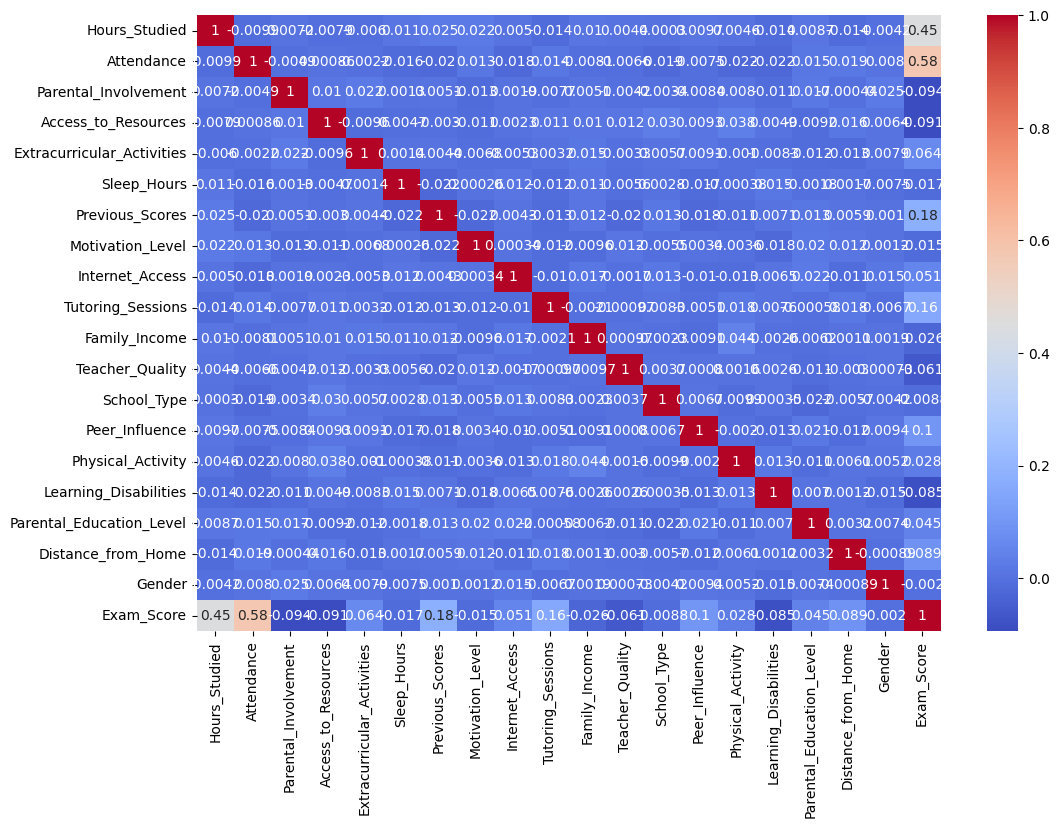

In [21]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

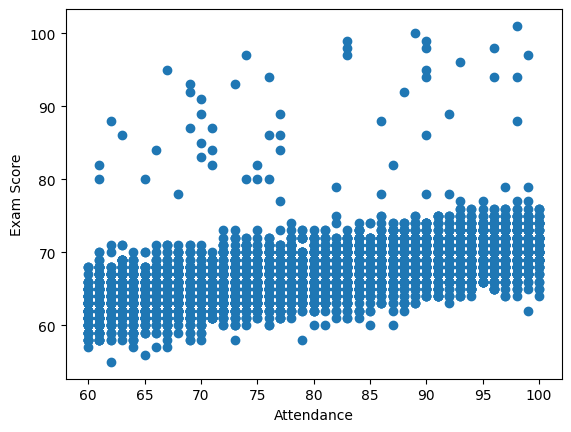

In [22]:
plt.scatter(
    df["Attendance"],
    df["Exam_Score"]
)

plt.xlabel("Attendance")

plt.ylabel("Exam Score")

plt.show()

In [23]:
X = df.drop("Exam_Score", axis=1)

In [24]:
y = df["Exam_Score"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [27]:
lr_pred = lr.predict(X_test)

In [28]:
print(
    "MAE:",
    mean_absolute_error(y_test, lr_pred)
)

print(
    "R²:",
    r2_score(y_test, lr_pred)
)

MAE: 1.0155490830845972
R²: 0.6887688020307757


In [29]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [30]:
print(
    mean_absolute_error(
        y_test,
        dt_pred
    )
)

print(
    r2_score(
        y_test,
        dt_pred
    )
)

1.7291981845688351
0.23046320299356693


In [31]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [32]:
print(
    mean_absolute_error(
        y_test,
        rf_pred
    )
)

print(
    r2_score(
        y_test,
        rf_pred
    )
)

1.1313993948562784
0.6546399715264632


Compare the models
Model with low MAE and high R^2 is best


In [33]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

print(importance)

                       Feature  Importance
1                   Attendance    0.380088
0                Hours_Studied    0.242312
6              Previous_Scores    0.091586
9            Tutoring_Sessions    0.035263
5                  Sleep_Hours    0.030049
14           Physical_Activity    0.028412
3          Access_to_Resources    0.027855
2         Parental_Involvement    0.027454
13              Peer_Influence    0.018911
10               Family_Income    0.018383
17          Distance_from_Home    0.017268
16    Parental_Education_Level    0.016512
7             Motivation_Level    0.013064
11             Teacher_Quality    0.012332
15       Learning_Disabilities    0.009278
4   Extracurricular_Activities    0.009131
12                 School_Type    0.008634
18                      Gender    0.007435
8              Internet_Access    0.006035


Q: Why did you choose Linear Regression even though Random Forest is more advanced?

Answer:

"I evaluated multiple models using MAE and R² score. Linear Regression achieved the lowest MAE and highest R² score on this dataset, indicating better generalization performance. Therefore, I selected it as the final model."

